In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split



In [2]:
# 1. Load the Uploaded Dataset
excel_path = "Task 1 dataset.xlsx"
df = pd.read_excel(excel_path)

print("--- Initial Dataset Preview ---")
print(df.head())



--- Initial Dataset Preview ---
   order_id  distance_km  cargo_weight_kg  traffic_delay_mins  \
0      1001        18.55             7.21                  20   
1      1002        26.31            12.45                  10   
2      1003         8.12             3.04                  45   
3      1004        31.42            14.89                  60   
4      1005        12.04             5.67                   0   

   delivery_time_mins  
0               73.42  
1               83.15  
2               68.90  
3              115.30  
4               52.80  


In [3]:
# 2. Data Cleaning & Preprocessing
df = df.drop_duplicates()
print(f"\nMissing Values Check: {df.isnull().sum().to_dict()}")




Missing Values Check: {'order_id': 0, 'distance_km': 0, 'cargo_weight_kg': 0, 'traffic_delay_mins': 0, 'delivery_time_mins': 0}


In [4]:
# 3. Exploratory Data Analysis (EDA) & KPI Calculations
avg_distance = df["distance_km"].mean()
avg_weight = df["cargo_weight_kg"].mean()
avg_traffic = df["traffic_delay_mins"].mean()
avg_delivery_time = df["delivery_time_mins"].mean()

print("\n--- Logistics Key Performance Indicators (KPIs) ---")
print(f"1. Average Distance: {avg_distance:.2f} km")
print(f"2. Average Cargo Weight: {avg_weight:.2f} kg")
print(f"3. Average Traffic Delay: {avg_traffic:.2f} mins")
print(f"4. Average Transit Time: {avg_delivery_time:.2f} mins")




--- Logistics Key Performance Indicators (KPIs) ---
1. Average Distance: 19.29 km
2. Average Cargo Weight: 8.65 kg
3. Average Traffic Delay: 27.00 mins
4. Average Transit Time: 78.71 mins


In [5]:
# 4. Predictive Modeling (Problem & Solution Implementation)
# Problem: Unpredictable delivery windows affecting supply chain SLAs.
# Solution: Linear regression model to forecast transit duration based on operational features.

X = df[["distance_km", "cargo_weight_kg", "traffic_delay_mins"]]
y = df["delivery_time_mins"]

# Note: For small datasets, ensure train/test split accommodates sample size
if len(df) > 5:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nModel R2 Score: {r2_score(y_test, y_pred):.4f}")
else:
    model = LinearRegression()
    model.fit(X, y)
    print(
        f"\nModel Coefficients (Distance, Weight, Traffic): {model.coef_}"
    )
    print(f"Intercept: {model.intercept_:.2f}")




Model Coefficients (Distance, Weight, Traffic): [1.52198262 0.3671682  0.49054511]
Intercept: 32.94


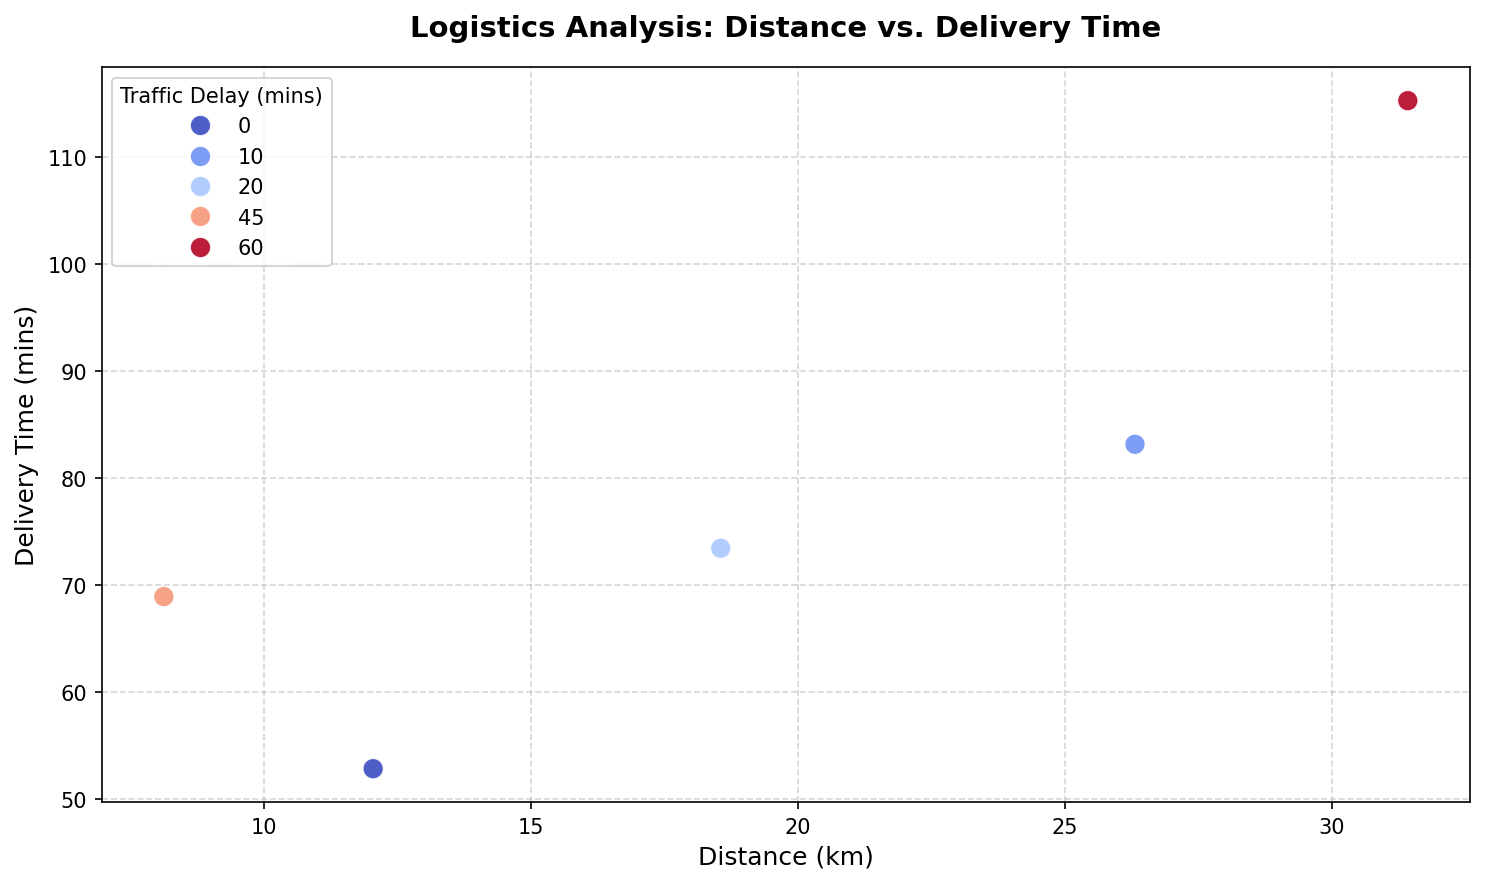


[Success] EDA visualization plot saved successfully as 'logistics_task_plot.png'.


In [6]:
# 5. Data Visualization
plt.figure(figsize=(10, 6), dpi=150)
sns.scatterplot(
    x="distance_km",
    y="delivery_time_mins",
    hue="traffic_delay_mins",
    data=df,
    palette="coolwarm",
    s=100,
    alpha=0.9,
)
plt.title(
    "Logistics Analysis: Distance vs. Delivery Time",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Distance (km)", fontsize=12)
plt.ylabel("Delivery Time (mins)", fontsize=12)
plt.legend(title="Traffic Delay (mins)", title_fontsize="10", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("logistics_task_plot.png")
plt.show()
print(
    "\n[Success] EDA visualization plot saved successfully as 'logistics_task_plot.png'."
)